Тема 2  завдання 1,2

xi: [1.   1.25 1.5  1.75 2.  ] [1.         1.47314355 1.90546511 2.30961579 2.69314718]
x: x
n: 5
L4= 1.0*(2.33333333333333 - 1.33333333333333*x)*(3.0 - 2.0*x)*(5.0 - 4.0*x) + 1.47314355131421*(3.5 - 2.0*x)*(6.0 - 4.0*x)*(4.0*x - 4.0) + 1.90546510810816*(7.0 - 4.0*x)*(2.0*x - 2.0)*(4.0*x - 5.0) + 2.30961578793542*(1.33333333333333*x - 1.33333333333333)*(2.0*x - 2.5)*(4.0*x - 6.0)
L4_simple: 0.134945253904625*x**3 - 0.832620658304364*x**2 + 3.25149190593038*x - 1.55381650153058
x==0,5 -0.119357556403400


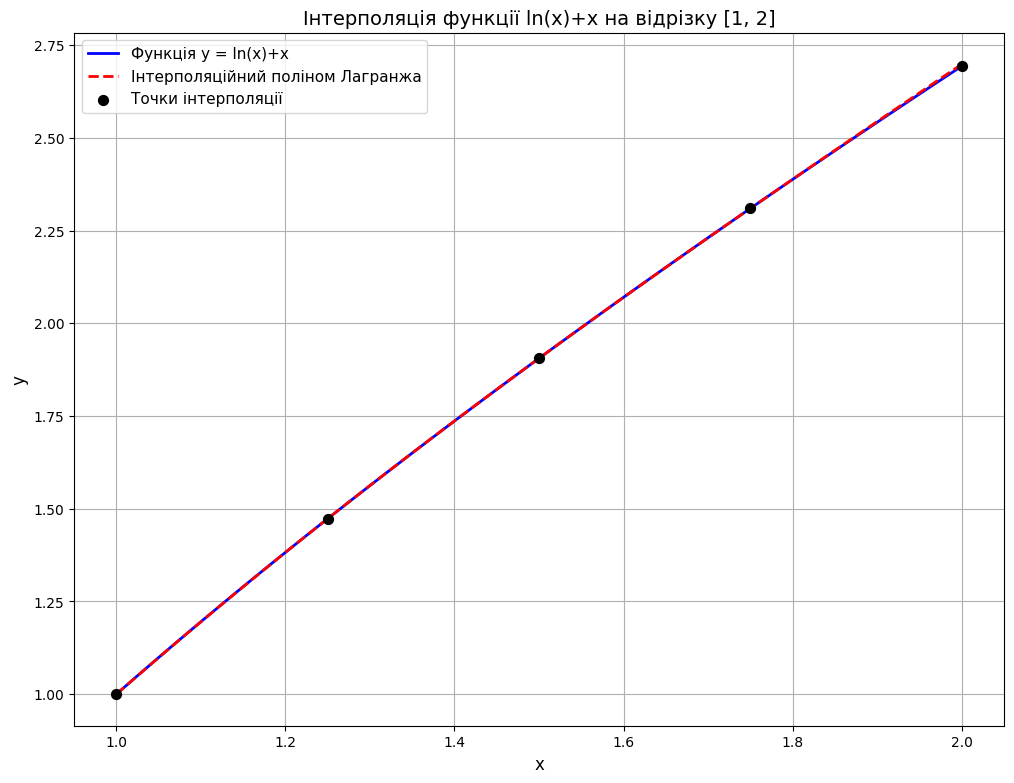

L4 x==1.4 1.73662545320969
f(1.4) 1.7364722366212129
L4(1.4)-f(1.4) 0.000153216588479888
24*(-1 + (x + 1)/x)/x**4
24/x**5


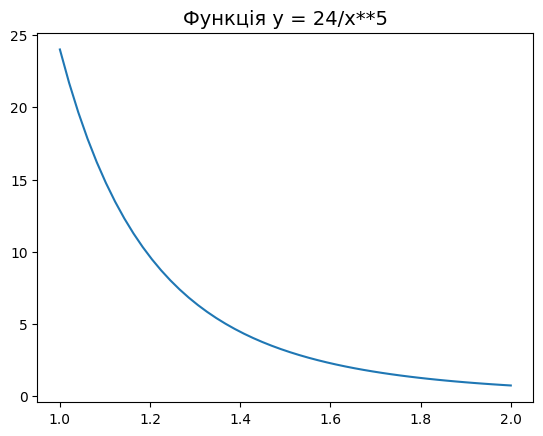

max df5= 24.0
   
x - 1.0      x - 1.0
(x - 1.25)*(x - 1.0)      x - 1.25
(x - 1.5)*(x - 1.25)*(x - 1.0)      x - 1.5
(x - 1.75)*(x - 1.5)*(x - 1.25)*(x - 1.0)      x - 1.75
(x - 2.0)*(x - 1.75)*(x - 1.5)*(x - 1.25)*(x - 1.0)      x - 2.0
w5= (x - 2.0)*(x - 1.75)*(x - 1.5)*(x - 1.25)*(x - 1.0)
w5(1.4)= 0.00126000000000000
L4(1.4)-f(1.4)= 0.000153216588479888
R4<= 0.000252000000000000


In [ ]:
import numpy as np
import math
from math import *
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
    return np.log(x)+x
    #return x**16

a=1
b=2
xi=np.linspace(a,b,5)
yi=f(xi)
print("xi:",xi, yi)

x=sp.Symbol("x")
print("x:",x)
n=len(xi)
print("n:",n)

L4=0
for m in range (n-1):
  pm=1
  for j in range(n-1):
    if m!=j:
      pm*=(x-xi[j])/(xi[m]-xi[j])
  L4+=yi[m]*pm
print("L4=",L4)

L4_simple=sp.expand(L4)#упрощенній
print("L4_simple:",L4_simple)
print("x==0,5",L4_simple.subs(x,0.5))

xx = np.linspace(a, b, 50)
yy_real = f(xx)
yy_interp = [L4_simple.subs(x, val) for val in xx]

plt.figure(figsize=(12,9))
plt.plot(xx, yy_real, label="Функція y = ln(x)+x", color="blue", linewidth=2)
plt.plot(xx, yy_interp, "--", label="Інтерполяційний поліном Лагранжа", color="red", linewidth=2)
plt.scatter(xi, yi, color="black", s=50, zorder=5, label="Точки інтерполяції")
plt.title("Інтерполяція функції ln(x)+x на відрізку [1, 2]", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True)
plt.show()


#дз посчитать похибку

print("L4 x==1.4",L4_simple.subs(x,1.4))
print("f(1.4)", f(1.4))
print("L4(1.4)-f(1.4)",abs(L4_simple.subs(x,1.4)-f(1.4)))

#M5=max y v po x є [1,2]
#f0=np.log(x)+x
f1=(x+1)/x
df5=sp.diff(f1,x,4)
print(df5)
print(sp.expand(df5))

"""
l1 = np.linspace(-10, 10, 50)
g1=24/l1**5
plt.plot(l1,g1)
plt.title("Функція y = 24/x**5", fontsize=14)
"""
l = np.linspace(1, 2, 50)
g=24/l**5
plt.plot(l,g)
plt.title("Функція y = 24/x**5", fontsize=14)
plt.show()
print("max df5=",max(g))

print("   ")
w5=1
for i in range(n):
  p=0
  p=p+(x-xi[i])
  w5=w5*p
  print(w5,'    ',p)
print("w5=",w5)
print("w5(1.4)=",abs(w5.subs(x,1.4)))

#тут все правильно с н

print("L4(1.4)-f(1.4)=",abs(L4_simple.subs(x,1.4)-f(1.4)))
print("R4<=",max(g)/120*abs(w5.subs(x,1.4)))